DATA ANALYSIS

In [1]:
import pandas as pd 
import numpy as np
import os
import sys


In [2]:
df=pd.read_csv("Rohit_Sharma_All_100_Nov_2023.csv")

In [3]:
df.head()

,Unnamed: 0,No.,Score,Against,Position,Innings,Venue,Ground,Date,Result
0,0,1,114,Zimbabwe,4,1,"Queens Sports Club, Bulawayo",Away,28-May-10,Lost
1,1,2,101*,Sri Lanka,4,2,"Queens Sports Club, Bulawayo",Neutral,30-May-10,Won
2,2,3,141*,Australia,1,2,"Sawai Mansingh Stadium, Jaipur",Home,16-Oct-13,Won
3,3,4,209,Australia,1,1,"M. Chinnaswamy Stadium, Bangalore",Home,02-Nov-13,Won
4,4,5,177,West Indies,6,2,"Eden Gardens, Kolkata",Home,06-Nov-13,Won


In [ ]:
df.tail

,Unnamed: 0,No.,Score,Against,Position,Innings,Venue,Ground,Date,Result
40,40,41,127,England,1,3,"The Oval, London",Away,02-Sep-21,Won
41,41,42,101,New Zealand,1,1,"Holkar Cricket Stadium, Indore",Home,24-Jan-23,Won
42,42,43,120,Australia,1,2,"Vidarbha Cricket Association Stadium, Nagpur",Home,09-Feb-23,Won
43,43,44,103,West Indies,1,1,"Windsor Park Sports Stadium, Dominica",Away,12-Jul-23,Won
44,44,45,131,Afghanistan,1,2,"Arun Jaitley Stadium, Delhi",Home,11-Oct-23,Won


In [5]:
df.isnull().sum()

Unnamed: 0    0
No.           0
Score         0
Against       0
Position      0
Innings       0
Venue         0
Ground        0
Date          0
Result        0
dtype: int64

In [6]:
df.describe()

,Unnamed: 0,No.,Position,Innings
count,45.000000,45.000000,45.000000,45.000000
mean,22.000000,23.000000,1.666667,1.533333
std,13.133926,13.133926,1.365151,0.587754
min,0.000000,1.000000,1.000000,1.000000
25%,11.000000,12.000000,1.000000,1.000000
50%,22.000000,23.000000,1.000000,1.000000
75%,33.000000,34.000000,2.000000,2.000000
max,44.000000,45.000000,6.000000,3.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  45 non-null     int64 
 1   No.         45 non-null     int64 
 2   Score       45 non-null     object
 3   Against     45 non-null     object
 4   Position    45 non-null     int64 
 5   Innings     45 non-null     int64 
 6   Venue       45 non-null     object
 7   Ground      45 non-null     object
 8   Date        45 non-null     object
 9   Result      45 non-null     object
dtypes: int64(4), object(6)
memory usage: 3.6+ KB


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')


DATA VISUALIZATION

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: title={'center': 'Top Againsts Rohit Scored Centuries Against'}, ylabel='Against'>

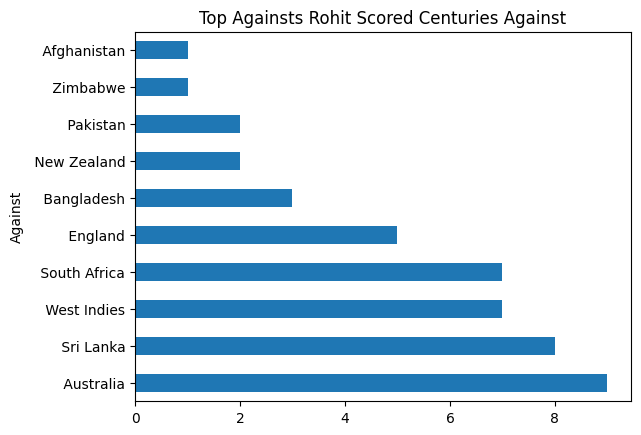

In [ ]:
df['Against'].value_counts().head(10).plot(kind='barh', title='Top Againsts Rohit Scored Centuries Against')

In [26]:
df['Year'] = df['Date'].dt.year


In [51]:
centuries_per_year = df.groupby('Year').size().reset_index(name='Centuries')
print(centuries_per_year)
present_centuries=sum(centuries_per_year['Centuries'])
print()
print(f"Total centuries till now: {present_centuries}")

    Year  Centuries
0   2010          2
1   2013          4
2   2014          1
3   2015          4
4   2016          2
5   2017          8
6   2018          7
7   2019         10
8   2020          1
9   2021          2
10  2023          4

Total centuries till now: 45


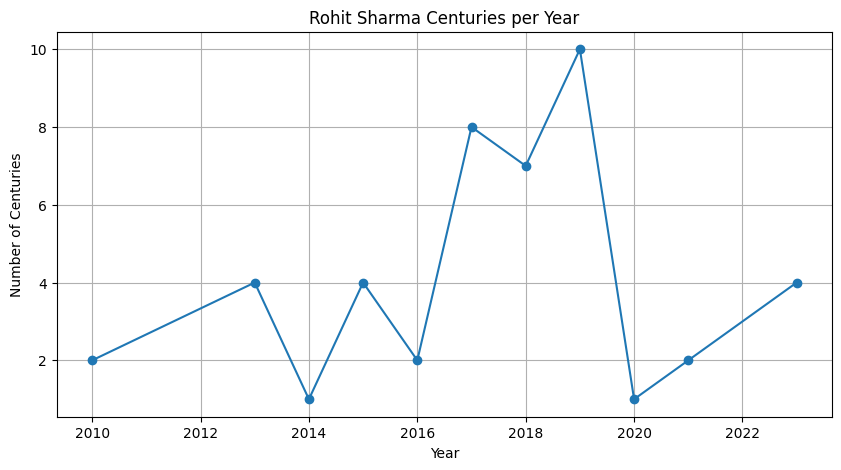

In [30]:
plt.figure(figsize=(10,5))
plt.plot(centuries_per_year['Year'], centuries_per_year['Centuries'], marker='o')
plt.title('Rohit Sharma Centuries per Year')
plt.xlabel('Year')
plt.ylabel('Number of Centuries')
plt.grid(True)
plt.show()

PREDICTION

PREDICTING HOW MANY CENTURIES WILL ROHIT SHAEMA HIT BEFORE 2027

In [31]:
from sklearn.linear_model import LinearRegression
import numpy as np

In [ ]:
X = centuries_per_year['Year'].values.reshape(-1, 1)
y = centuries_per_year['Centuries'].values

In [33]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [ ]:
future_years = np.array([[2024], [2025], [2026], [2027]])
predictions = model.predict(future_years)

predictions = [round(i) for i in predictions]

total_centuries = present_centuries + sum(predictions)
final = round(total_centuries)

print(f"Predicted centuries in 2024: {predictions[0]}")
print(f"Predicted centuries in 2025: {predictions[1]}")
print(f"Predicted centuries in 2026: {predictions[2]}")
print(f"Predicted centuries in 2027: {predictions[3]}")
print(f"Total centuries by 2027 (Assuming that he will retire in 2027): {final}")


Predicted centuries in 2024: 5
Predicted centuries in 2025: 5
Predicted centuries in 2026: 6
Predicted centuries in 2027: 6
Total centuries by 2027 (Assuming that he will retire in 2027): 67
